⚙️ Installing PostgreSQL system packages...
 Configuring and starting PostgreSQL database service...
 * Restarting PostgreSQL 14 database server
   ...done.
DROP DATABASE
CREATE DATABASE
ALTER ROLE

 Connecting to 'retail_analytics' database securely...
 Structuring normalized relational schemas...
 Parsing raw data and normalizing schemas...
 Running streaming ETL ingestion loops...
 Data pipeline complete! Loaded 9994 operational transaction records.

 RUNNING ADVANCED BUSINESS INTEL QUERIES...

 Rendering Visual Analytics Dashboard...


/tmp/ipykernel_1815/1722888753.py:136: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_profit = pd.read_sql_query(profit_query, conn)
/tmp/ipykernel_1815/1722888753.py:148: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_season = pd.read_sql_query(season_query, conn)
/tmp/ipykernel_1815/1722888753.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_profit, x='sub_category', y='net_profit', palette='coolwarm', ax=axes[0])


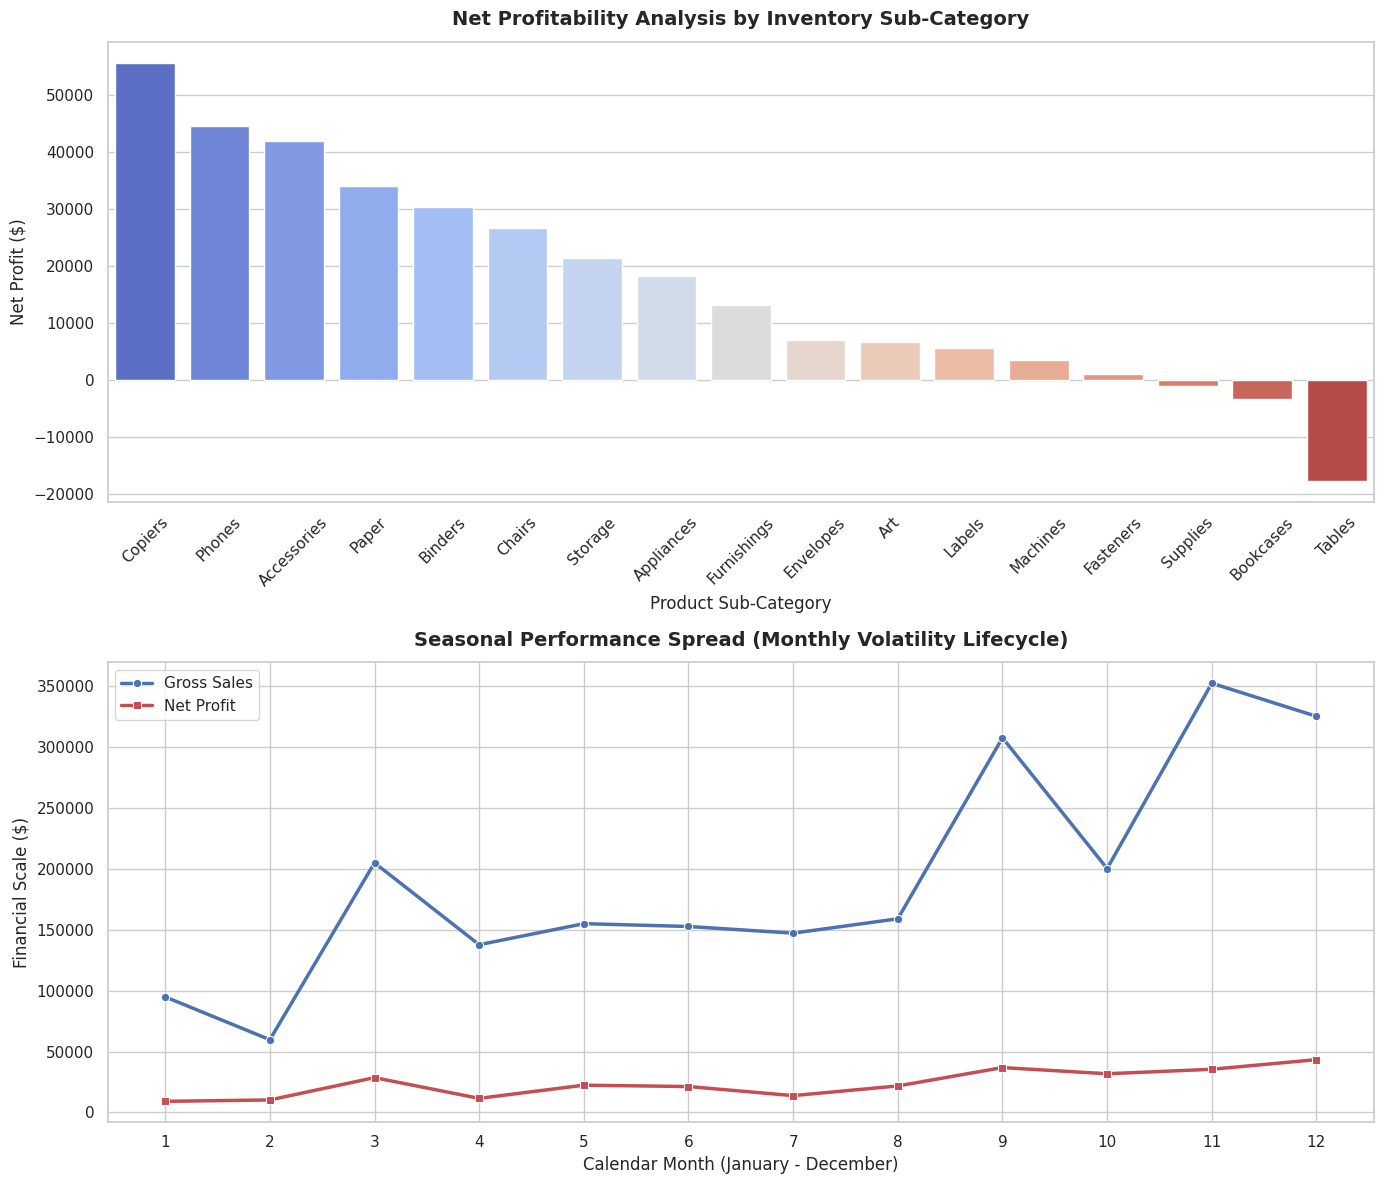

 Pipeline execution finished. Connection pools cleanly dissolved.


In [4]:
# =====================================================================
# STEP 1: INSTALL, RUN, & CONFIG POSTGRESQL (FIXES AUTHENTICATION ERROR)
# =====================================================================
print("⚙️ Installing PostgreSQL system packages...")
!apt-get update &> /dev/null
!apt-get install postgresql postgresql-contrib &> /dev/null

print(" Configuring and starting PostgreSQL database service...")
# Fix local authentication settings to allow passwordless connections on localhost
!sed -i 's/local   all             all                                     peer/local   all             all                                     trust/' /etc/postgresql/*/main/pg_hba.conf
!sed -i 's/host    all             all             127.0.0.1\/32            scram-sha-256/host    all             all             127.0.0.1\/32            trust/' /etc/postgresql/*/main/pg_hba.conf
!sed -i 's/host    all             all             ::1\/128                 scram-sha-256/host    all             all             ::1\/128                 trust/' /etc/postgresql/*/main/pg_hba.conf

# Restart the service to apply changes
!service postgresql restart

# Provision the structural project database safely
!sudo -u postgres psql -c "DROP DATABASE IF EXISTS retail_analytics;"
!sudo -u postgres psql -c "CREATE DATABASE retail_analytics;"
!sudo -u postgres psql -c "ALTER USER postgres WITH SUPERUSER;"

# =====================================================================
# STEP 2: FILE UPLOADER FROM YOUR COMPUTER
# =====================================================================
import os
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

csv_filename = "Sample - Superstore.csv"

if not os.path.exists(csv_filename):
    print(f"\n '{csv_filename}' not found in the environment. Please upload it from your computer now:")
    uploaded = files.upload()
    for filename in uploaded.keys():
        if "superstore" in filename.lower() and filename != csv_filename:
            os.rename(filename, csv_filename)

# =====================================================================
# STEP 3: DATABASE SCHEMA CREATION (DDL)
# =====================================================================
print("\n Connecting to 'retail_analytics' database securely...")
conn = psycopg2.connect(database="retail_analytics", user="postgres", host="localhost")
conn.autocommit = True
cursor = conn.cursor()

print(" Structuring normalized relational schemas...")
schema_queries = """
CREATE TABLE Customers (
    customer_id VARCHAR(50) PRIMARY KEY,
    customer_name VARCHAR(100),
    segment VARCHAR(50)
);

CREATE TABLE Products (
    product_id VARCHAR(50) PRIMARY KEY,
    product_name VARCHAR(255),
    category VARCHAR(50),
    sub_category VARCHAR(50)
);

CREATE TABLE Orders (
    row_id INT PRIMARY KEY,
    order_id VARCHAR(50),
    order_date DATE,
    ship_date DATE,
    ship_mode VARCHAR(50),
    customer_id VARCHAR(50) REFERENCES Customers(customer_id),
    country VARCHAR(50),
    city VARCHAR(50),
    state VARCHAR(50),
    postal_code VARCHAR(20),
    region VARCHAR(50),
    product_id VARCHAR(50) REFERENCES Products(product_id),
    sales NUMERIC(10, 2),
    quantity INT,
    discount NUMERIC(5, 2),
    profit NUMERIC(10, 4)
);
"""
cursor.execute(schema_queries)

# =====================================================================
# STEP 4: CLEAN AND PIPELINE CSV RECORDS INTO SQL
# =====================================================================
print(" Parsing raw data and normalizing schemas...")
df = pd.read_csv(csv_filename, encoding="ISO-8859-1")

df['Order Date'] = pd.to_datetime(df['Order Date']).dt.strftime('%Y-%m-%d')
df['Ship Date'] = pd.to_datetime(df['Ship Date']).dt.strftime('%Y-%m-%d')
df['Postal Code'] = df['Postal Code'].fillna(0).astype(int).astype(str)

customers_df = df[['Customer ID', 'Customer Name', 'Segment']].drop_duplicates(subset=['Customer ID'])
products_df = df[['Product ID', 'Product Name', 'Category', 'Sub-Category']].drop_duplicates(subset=['Product ID'])

print(" Running streaming ETL ingestion loops...")
for _, row in customers_df.iterrows():
    cursor.execute("INSERT INTO Customers VALUES (%s, %s, %s) ON CONFLICT DO NOTHING;",
                   (row['Customer ID'], row['Customer Name'], row['Segment']))

for _, row in products_df.iterrows():
    cursor.execute("INSERT INTO Products VALUES (%s, %s, %s, %s) ON CONFLICT DO NOTHING;",
                   (row['Product ID'], row['Product Name'], row['Category'], row['Sub-Category']))

order_count = 0
for _, row in df.iterrows():
    cursor.execute("""
        INSERT INTO Orders VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s);
    """, (
        int(row['Row ID']), row['Order ID'], row['Order Date'], row['Ship Date'], row['Ship Mode'],
        row['Customer ID'], row['Country'], row['City'], row['State'], row['Postal Code'], row['Region'],
        row['Product ID'], float(row['Sales']), int(row['Quantity']), float(row['Discount']), float(row['Profit'])
    ))
    order_count += 1

print(f" Data pipeline complete! Loaded {order_count} operational transaction records.")

# =====================================================================
# STEP 5: RUN QUANTITATIVE SQL REVENUE REPORTS
# =====================================================================
print("\n RUNNING ADVANCED BUSINESS INTEL QUERIES...")

# Query 1: Product Inventory Performance Metrics
profit_query = """
SELECT
    p.sub_category,
    ROUND(SUM(o.sales), 2) AS gross_sales,
    ROUND(SUM(o.profit), 2) AS net_profit
FROM Orders o
JOIN Products p ON o.product_id = p.product_id
GROUP BY p.sub_category
ORDER BY net_profit DESC;
"""
df_profit = pd.read_sql_query(profit_query, conn)

# Query 2: Cyclical Seasonality Trends
season_query = """
SELECT
    EXTRACT(MONTH FROM order_date) AS calendar_month,
    ROUND(SUM(sales), 2) AS gross_sales,
    ROUND(SUM(profit), 2) AS net_profit
FROM Orders
GROUP BY calendar_month
ORDER BY calendar_month ASC;
"""
df_season = pd.read_sql_query(season_query, conn)
df_season['calendar_month'] = df_season['calendar_month'].astype(int)

# =====================================================================
# STEP 6: GENERATE THE RETAIL ANALYTICS DASHBOARD
# =====================================================================
print("\n Rendering Visual Analytics Dashboard...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Subplot 1: Profitability Landscape across Subcategories
sns.barplot(data=df_profit, x='sub_category', y='net_profit', palette='coolwarm', ax=axes[0])
axes[0].set_title('Net Profitability Analysis by Inventory Sub-Category', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Product Sub-Category', fontsize=12)
axes[0].set_ylabel('Net Profit ($)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Subplot 2: Holiday Demand Spikes and Seasonal Volume Cycles
sns.lineplot(data=df_season, x='calendar_month', y='gross_sales', marker='o', color='b', linewidth=2.5, label='Gross Sales', ax=axes[1])
sns.lineplot(data=df_season, x='calendar_month', y='net_profit', marker='s', color='r', linewidth=2.5, label='Net Profit', ax=axes[1])
axes[1].set_title('Seasonal Performance Spread (Monthly Volatility Lifecycle)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Calendar Month (January - December)', fontsize=12)
axes[1].set_ylabel('Financial Scale ($)', fontsize=12)
axes[1].set_xticks(range(1, 13))
axes[1].legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

# Safely close active connections
cursor.close()
conn.close()
print(" Pipeline execution finished. Connection pools cleanly dissolved.")